In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

In [ ]:
# Load data set
# cleaned data
data = pd.read_csv(r"..\..\..\Datasets\For analysis\full_data_CIFAR100_v3.csv")
# used to generate Results
#data = pd.read_csv(r"data.csv")

# Ensure we only have data with 80/20 datasplit
split_07 = [3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 39110, 39111, 39112, 39113, 39114, 39115]
split_09 = [3901,3902,3903,3904,3905,3906,3907,3908,3909,39010,39011,39012,39013,39014,39015]
split = split_07 + split_09
data = data[~data["exp_id"].isin(split)]

# Rename names for readbility
rename_map = {
    "vit_l_32": "ViT-L/32",
    "vit_b_16": "ViT-B/16",
    "vit_b_32": "ViT-B/32",
    "vit_small_patch16_224": "ViT-S/16",
    "vit_small_patch32_224": "ViT-S/32",
    "vit_tiny_patch16_224": "ViT-T/16",
}

data["model"] = data["model"].replace(rename_map)


In [4]:
# Functions to analyse
def make_subset(df, model, bs, lr, do_to_assess):
# Freeze other hyperparameters so can get all configurations when changing batch rate while freezing other parameters

    subset = df[
        (df["model"] == model) &
        (df["batch_size"] == bs) &
        (df["dropout"].isin(do_to_assess)) &
        (df["lr"] == lr) & 
        (df["weight_decay"] == 0.0)
        
    ]
    return subset

def summary_table(subset):
    # Summary table that takes mean of every configuration
    view = (
        subset
        .groupby(["dropout", "batch_size", "model", "lr"])
        .agg(
            accuracy=("accuracy", "mean"),
            precision=("precision", "mean"),
            recall=("recall", "mean"),
            specificity=("specificity", "mean"),
            energy=("total_energy_J", "mean"),
            energy_std=("total_energy_J", "std"),
            n_seeds=("accuracy", "nunique"),
            Eg=("Eg","mean"),
            Pg=("Pg", "mean"),
            FPJ=("FPJ", "mean"),
            EDPinv=("EDPinv", "mean"),
            SPJ=("SPJ", "mean"),
        )
        .reset_index()
    )
    print("=========================================")
    print("View for plotting")
    print(view)
    print("=========================================")
    return view

def rank(results_df, metric, ascending = False):
 # Rank drop on a given metric, ie "accuracy" or "SPJ"
    df = results_df 
    return (
        df.groupby("dropout")[metric]
        .mean()
        .sort_values(ascending=ascending)
        .reset_index()
        .rename(columns={metric: f"{metric}"})
    )


In [5]:
do_to_assess = [0.025, 0.075, 0.01 , 0.0, 0.1, 0.05]
vit_b_32 = make_subset(data,"ViT-B/32",128, 0.03, do_to_assess)
vit_b_32 = summary_table(vit_b_32)


vit_b_32 = vit_b_32.dropna()
selected = vit_b_32
print("ViT-B/32")  
Eg = rank(selected,"Eg", ascending=False)
Pg = rank(selected, "Pg", ascending=False)
ac = rank(selected, "accuracy", ascending=False)
re = rank(selected, "recall", ascending=False)
sp = rank(selected, "specificity", ascending=False)
pre = rank(selected, "precision", ascending=False)
fpj = rank(selected, "FPJ", ascending=False)
edpinv = rank(selected, "EDPinv", ascending=False)
spj = rank(selected, "SPJ", ascending=False)
selected["EgPg"] = selected["Pg"] / selected["Eg"]
EgPg = rank(selected,"EgPg", ascending=False)
energy = rank(selected,"energy", ascending=True)


print("==========================================================================================")
print("PERFORMANCE")
print("==========================================================================================")
print("\n")
final = pd.concat([Pg, ac, re, sp, pre], axis=1)
print(final.to_markdown(index=False))

print("==========================================================================================")
print("ENERGY EFFICIENCY")
print("==========================================================================================")
print("\n")
final = pd.concat([Eg, spj, edpinv, fpj, energy], axis=1).dropna()
print(final.to_markdown(index=False))

print("==========================================================================================")
print("ENERGY EFFICIENCY 2")
print("==========================================================================================")
print("\n")
final = pd.concat([EgPg, Eg, Pg, energy], axis=1).dropna()
print(final.to_markdown(index=False))

View for plotting
   dropout  batch_size     model    lr  accuracy  precision    recall  \
0    0.000         128  ViT-B/32  0.03  0.860072   0.859973  0.860095   
1    0.010         128  ViT-B/32  0.03  0.862229   0.862000  0.862136   
2    0.025         128  ViT-B/32  0.03  0.864389   0.864422  0.864477   
3    0.050         128  ViT-B/32  0.03  0.865000   0.864810  0.864807   
4    0.075         128  ViT-B/32  0.03  0.862287   0.862383  0.861918   
5    0.100         128  ViT-B/32  0.03  0.858600   0.858970  0.858460   

   specificity         energy    energy_std  n_seeds  Eg        Pg  \
0     0.998587  235497.573596  89773.945547       17 NaN  0.635291   
1     0.998608  155921.050014   1076.649734        6 NaN  0.639906   
2     0.998630  156412.931498    803.741590        9 NaN  0.645086   
3     0.998636  156173.190562    698.557840       14 NaN  0.646063   
4     0.998609  156421.763588    742.520789        8 NaN  0.640066   
5     0.998572  156007.623454   1388.310723       

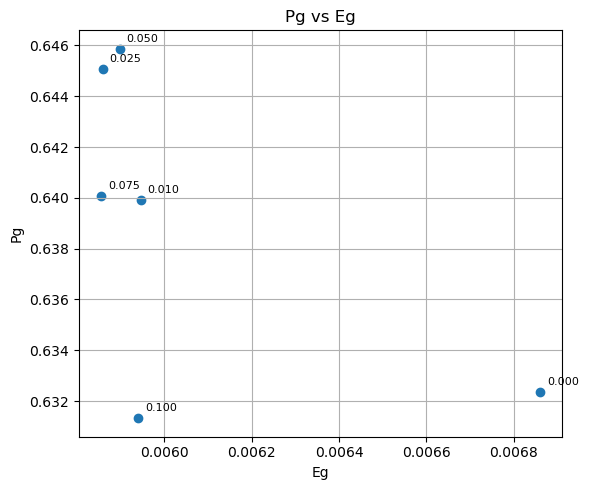

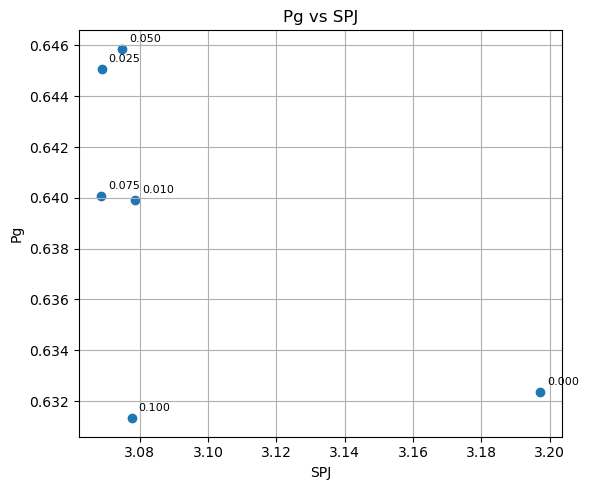

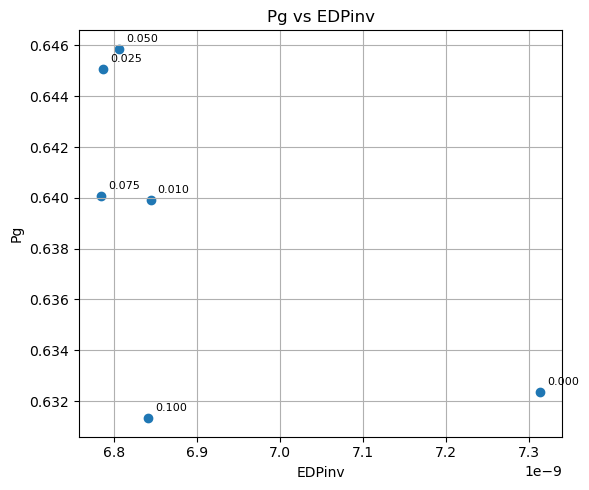

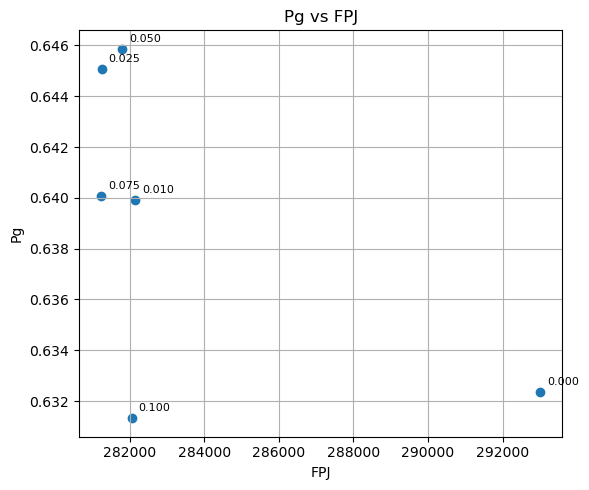

In [10]:
# The code for plotting plot_dropout is partly written with help of chatGPT


def plot_dropout(df):
    pairs = [
        ("Eg", "Pg vs Eg"),
        ("SPJ", "Pg vs SPJ"),
        ("EDPinv", "Pg vs EDPinv"),
        ("FPJ", "Pg vs FPJ")
    ]

    for xcol, title in pairs:
        plt.figure(figsize=(6, 5))
        plt.scatter(df[xcol], df["Pg"])

        # Annotate dropout
        for _, row in df.iterrows():
            plt.annotate(
                f"{row['dropout']:.3f}",
                (row[xcol], row["Pg"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

        plt.xlabel(xcol)
        plt.ylabel("Pg")
        plt.title(title)
        plt.grid(True)

        plt.tight_layout()
        plt.show()

plot_dropout(vit_b_32)

### Comments on plots Pg vs energy efficiency plots

Dropout rate increases Pg. The most increase is found by  0.025 and 0.050.  0.1 has the least, and is placed far lower than the other dropouts, barely higher on Pg than zero dropout.

However all dropout rates are less energy efficient. Seems like they are all aroundt the same energy efficiency value. See no pattern either, no finding that increasing dropout is increasing Eg.